<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
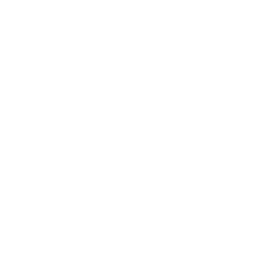
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Building Energy Efficiency Clustering</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Energy / Sustainability Analytics &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Shrnutí pro vedení

Tento praktický příklad shlukuje portfolio komerčních budov podle pěti metrik energetické účinnosti — energetické náročnosti (EUI), poměru účinnosti HVAC, tepelného odporu obálky budovy, hustoty výkonu osvětlení a podílu obnovitelných zdrojů — aby odhalil odlišné úrovně výkonnosti pro cílení rabatů od dodavatele energií. Analýza používá **PROC FASTCLUS** s volbou `REPLACE=FULL` (úplná náhrada počátečních center) a porovnává řešení pro k=3, 4, 5 a 6 z hlediska celkového R-kvadrátu, pseudo-F statistiky a minimální velikosti shluku. Řešení k=4 je poté podrobně profilováno a každý shluk je přiřazen k praktické úrovni účinnosti. Protože toto prostředí běží v nelicencovaném režimu, ukázka je omezena na vzorek 100 budov; stejný program se beze změny škáluje na celé portfolio.

## Zdroje dat

| Zdroj | Popis | Záznamy |
|--------|-------------|---------|
| WORK.BUILDING_METRICS | Roční metriky energetické účinnosti na budovu (syntetické) | 100 |


---

In [1]:
/* --------------------------------------------------------
   Generuj syntetické energetické metriky budov
   Ukazatele účinnosti komerčních budov
   -------------------------------------------------------- */
data work.building_metrics;
    CALL streaminit(42);
    DÉLKA building_type $20 climate_region $20;
    OPAKUJ building_id = 1 TO 5000;
        type_idx = int(rand('uniform') * 5) + 1;
        KDYŽ type_idx = 1 PAK building_type = 'KANCELÁŘ';
        JINAK KDYŽ type_idx = 2 PAK building_type = 'OBCHOD';
        JINAK KDYŽ type_idx = 3 PAK building_type = 'SKLAD';
        JINAK KDYŽ type_idx = 4 PAK building_type = 'NEMOCNICE';
        JINAK building_type = 'ŠKOLA';
        reg_idx = int(rand('uniform') * 4) + 1;
        KDYŽ reg_idx = 1 PAK climate_region = 'SEVEROVÝCHOD';
        JINAK KDYŽ reg_idx = 2 PAK climate_region = 'JIHOVÝCHOD';
        JINAK KDYŽ reg_idx = 3 PAK climate_region = 'STŘEDOZÁPAD';
        JINAK climate_region = 'ZÁPAD';

        /* Energetická náročnost (kBtu/sqft/rok) */
        eui = round(rand('normal', 85, 35), 0.1);
        KDYŽ eui < 15 PAK eui = 15;
        KDYŽ eui > 250 PAK eui = 250;

        /* Poměr účinnosti HVAC (ekvivalent COP) */
        hvac_efficiency = round(rand('normal', 3.2, 0.9), 0.01);
        KDYŽ hvac_efficiency < 1.0 PAK hvac_efficiency = 1.0;
        KDYŽ hvac_efficiency > 6.0 PAK hvac_efficiency = 6.0;

        /* Tepelný odpor obálky budovy (R-hodnota) */
        envelope_r_value = round(rand('normal', 18, 6), 0.1);
        KDYŽ envelope_r_value < 5 PAK envelope_r_value = 5;
        KDYŽ envelope_r_value > 40 PAK envelope_r_value = 40;

        /* Hustota výkonu osvětlení (W/sqft) */
        lighting_wpf = round(rand('normal', 1.1, 0.35), 0.01);
        KDYŽ lighting_wpf < 0.3 PAK lighting_wpf = 0.3;
        KDYŽ lighting_wpf > 2.5 PAK lighting_wpf = 2.5;

        /* Podíl obnovitelných zdrojů energie (%) */
        renewable_pct = round(rand('exponential') * 12, 0.1);
        KDYŽ renewable_pct > 80 PAK renewable_pct = 80;

        /* Stáří budovy v letech */
        building_age = int(rand('uniform') * 80) + 1;

        /* Podlahová plocha (tisíce sqft) */
        floor_area_ksf = round(rand('exponential') * 50 + 5, 0.1);
        KDYŽ floor_area_ksf > 500 PAK floor_area_ksf = 500;

        VÝSTUP;
    KONEC;
    ODSTRANIT type_idx reg_idx;
SPUSTIT;


NOTE: DATA work.building_metrics

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.building_metrics (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  1.84 seconds
  cpu   1.84 seconds


---

In [2]:
/* --------------------------------------------------------
   Základní rozdělení energetických metrik podle typu budovy
   -------------------------------------------------------- */
PROCEDURA PRŮMĚRY data=work.building_metrics n mean std;
    TŘÍDA building_type;
    PROMĚNNÁ eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    ŠTÍTEK building_type='Typ budovy'
          eui='Energetická náročnost (EUI)'
          hvac_efficiency='Účinnost HVAC'
          envelope_r_value='Tepelný odpor obálky (R)'
          lighting_wpf='Hustota osvětlení (W/sqft)'
          renewable_pct='Podíl obnovitelných zdrojů (%)';
    NÁZEV 'Energetické metriky podle typu budovy';
SPUSTIT;

                                         Energetické metriky podle typu budovy                                          

                                                  The MEANS Procedure

                                 Analysis Variable : eui Energetická náročnost (EUI)

        Typ budovy          N Obs           Mean        Std Dev
        -------------------------------------------------------
        KANCELÁŘ               20     73.0550000     40.3950163
        NEMOCNICE              25     87.9040000     35.2632892
        OBCHOD                 16     79.7312500     42.6818106
        SKLAD                  20     90.8900000     33.5993249
        ŠKOLA                  19     89.7000000     39.0498542
        -------------------------------------------------------

                                  Analysis Variable : hvac_efficiency Účinnost HVAC

        Typ budovy          N Obs           Mean        Std Dev
        ---------------------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                         Energetické metriky podle typu budovy                                          




NOTE: PROC SGPLOT data=work.building_metrics

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


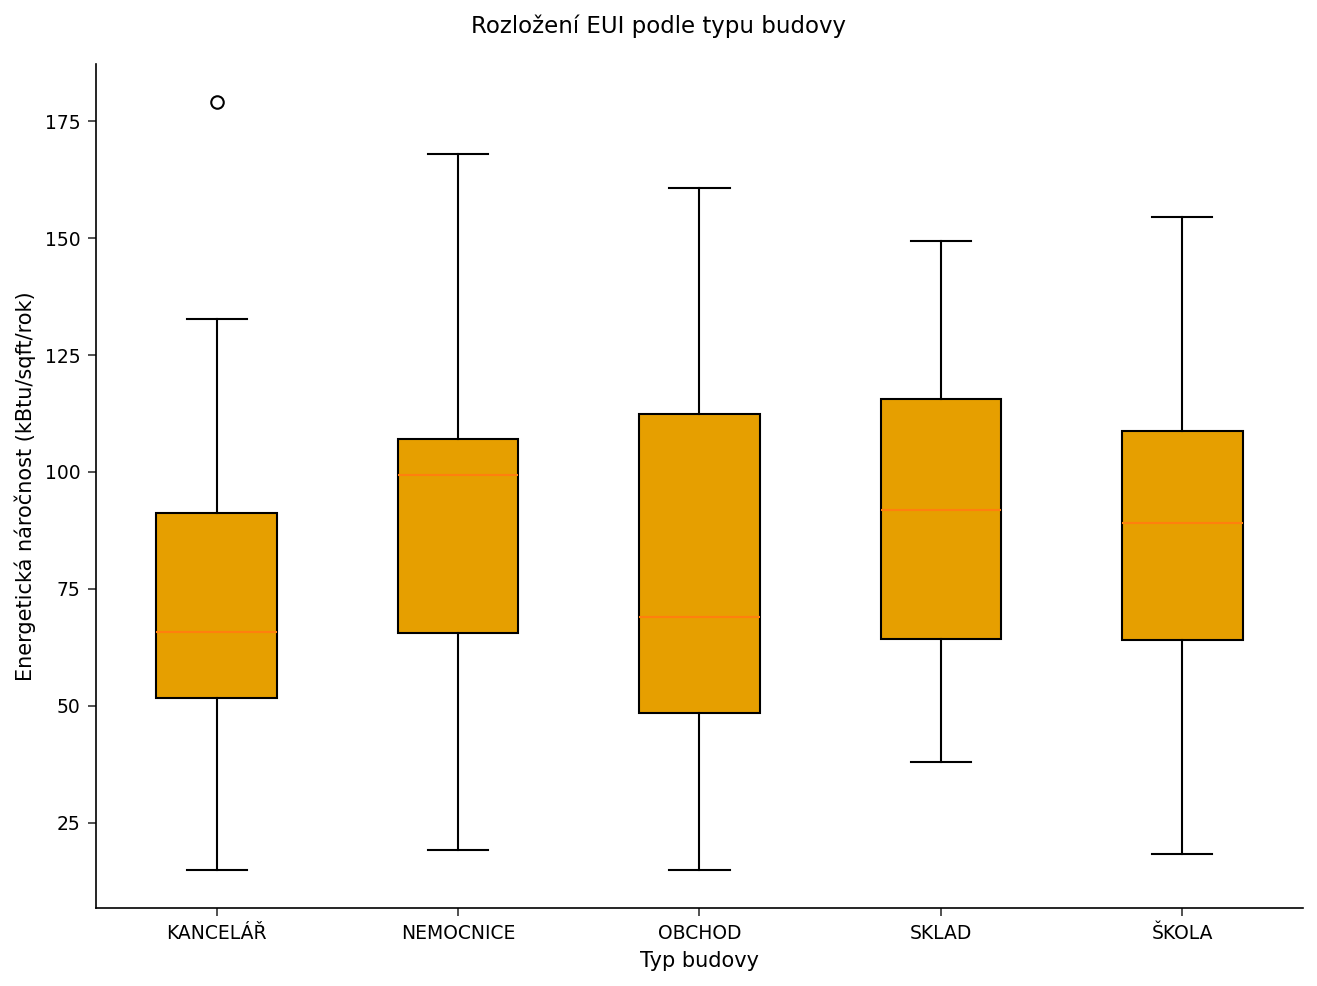

In [3]:
/* --------------------------------------------------------
   Rozložení EUI podle typu budovy
   -------------------------------------------------------- */
PROCEDURA SGPLOT data=work.building_metrics;
    VBOX eui / category=building_type;
    XAXIS ŠTÍTEK='Typ budovy';
    YAXIS ŠTÍTEK='Energetická náročnost (kBtu/sqft/rok)';
    NÁZEV 'Rozložení EUI podle typu budovy';
SPUSTIT;

---

In [4]:
/* --------------------------------------------------------
   Standardizace metrik účinnosti
   -------------------------------------------------------- */
PROCEDURA STANDARD data=work.building_metrics out=work.bldg_std
    mean=0 std=1;
    PROMĚNNÁ eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
SPUSTIT;


NOTE: PROC STANDARD data=work.building_metrics

NOTE: Standardized 100 rows, 5 variables.


In [5]:
/* --------------------------------------------------------
   Shlukování metodou k-průměrů: k=3 s REPLACE=FULL
   -------------------------------------------------------- */
PROCEDURA FASTCLUS data=work.bldg_std
    maxclusters=3 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust3
    mean=work.bldg_cent3;
    PROMĚNNÁ eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    ŠTÍTEK eui='Energetická náročnost (EUI)'
          hvac_efficiency='Účinnost HVAC'
          envelope_r_value='Tepelný odpor obálky (R)'
          lighting_wpf='Hustota osvětlení (W/sqft)'
          renewable_pct='Podíl obnovitelných zdrojů (%)';
    NÁZEV 'Shlukování energetické účinnosti budov: k=3 REPLACE=FULL';
SPUSTIT;

                                         Energetické metriky podle typu budovy                                          


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  35         0.9415             4.1984              2         2.0552
2                  34         0.7507             2.8107              3         2.0128
3                  31         0.8188             3.1310              2         2.0128




NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 3 clusters using k-means


In [6]:
/* --------------------------------------------------------
   Shlukování metodou k-průměrů: k=4 s REPLACE=FULL
   -------------------------------------------------------- */
PROCEDURA FASTCLUS data=work.bldg_std
    maxclusters=4 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust4
    mean=work.bldg_cent4;
    PROMĚNNÁ eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    ŠTÍTEK eui='Energetická náročnost (EUI)'
          hvac_efficiency='Účinnost HVAC'
          envelope_r_value='Tepelný odpor obálky (R)'
          lighting_wpf='Hustota osvětlení (W/sqft)'
          renewable_pct='Podíl obnovitelných zdrojů (%)';
    NÁZEV 'Shlukování energetické účinnosti budov: k=4 REPLACE=FULL';
SPUSTIT;

                                         Energetické metriky podle typu budovy                                          


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=4  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  23         0.7381             2.6617              3         2.1458
2                  17         1.0066             3.3423              4         2.2482
3                  26         0.7024             2.4365              4         2.0389
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 4 clusters using k-means


In [7]:
/* --------------------------------------------------------
   Shlukování metodou k-průměrů: k=5 s REPLACE=FULL
   -------------------------------------------------------- */
PROCEDURA FASTCLUS data=work.bldg_std
    maxclusters=5 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust5
    mean=work.bldg_cent5;
    PROMĚNNÁ eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    ŠTÍTEK eui='Energetická náročnost (EUI)'
          hvac_efficiency='Účinnost HVAC'
          envelope_r_value='Tepelný odpor obálky (R)'
          lighting_wpf='Hustota osvětlení (W/sqft)'
          renewable_pct='Podíl obnovitelných zdrojů (%)';
    NÁZEV 'Shlukování energetické účinnosti budov: k=5 REPLACE=FULL';
SPUSTIT;

                                         Energetické metriky podle typu budovy                                          


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=5  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  13         1.0052             3.3289              3         2.4004
2                  23         0.7401             2.5412              5         2.2053
3                  23         0.6853             2.6810              5         1.7721
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=5

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 5 clusters using k-means


In [8]:
/* --------------------------------------------------------
   Shlukování metodou k-průměrů: k=6 s REPLACE=FULL
   -------------------------------------------------------- */
PROCEDURA FASTCLUS data=work.bldg_std
    maxclusters=6 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust6
    mean=work.bldg_cent6;
    PROMĚNNÁ eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    ŠTÍTEK eui='Energetická náročnost (EUI)'
          hvac_efficiency='Účinnost HVAC'
          envelope_r_value='Tepelný odpor obálky (R)'
          lighting_wpf='Hustota osvětlení (W/sqft)'
          renewable_pct='Podíl obnovitelných zdrojů (%)';
    NÁZEV 'Shlukování energetické účinnosti budov: k=6 REPLACE=FULL';
SPUSTIT;

                                         Energetické metriky podle typu budovy                                          


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=6  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  19         0.5566             1.5459              5         1.9665
2                  10         0.9173             2.8197              3         2.3575
3                  18         0.8051             2.7522              4         1.8819
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=6

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 6 clusters using k-means


In [9]:
/* --------------------------------------------------------
   Porovnání kvality shluků napříč k=3-6
   Výpočet R-kvadrátu uvnitř shluků a minimální velikosti shluku
   -------------------------------------------------------- */
%macro cluster_quality(k);
PROCEDURA ČETNOSTI data=work.bldg_clust&k NOPRINT;
    TABLES CLUSTER / out=work.freq_k&k (PŘEJMENOVAT=(count=n_buildings));
SPUSTIT;

PROCEDURA SQL NOPRINT;
    VYBRAT MIN(n_buildings) INTO :min_size_k&k
    FROM work.freq_k&k;
QUIT;
%mend;

%cluster_quality(3);
%cluster_quality(4);
%cluster_quality(5);
%cluster_quality(6);

                                         Energetické metriky podle typu budovy                                          

                                         Energetické metriky podle typu budovy                                          

                                         Energetické metriky podle typu budovy                                          

                                         Energetické metriky podle typu budovy                                          




NOTE: PROC FREQ
NOTE: Output dataset work.freq_k3 has 3 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K3 = 31
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k4 has 4 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K4 = 17
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k5 has 5 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K5 = 13
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k6 has 6 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K6 = 10
NOTE: PROC SQL statement used.


                                    Profily úrovní energetické účinnosti budov (k=4)                                    

                                                  The MEANS Procedure

                                    Analysis Variable : eui Energetická náročnost (EUI)

                                                 N
                                    CLUSTER    Obs             Mean         Std Dev
                                    -----------------------------------------------
                                    1           23       63.7782609      31.5423086
                                    2           17      122.5941176      36.0679995
                                    3           26       94.0076923      30.8825378
                                    4           34       72.3911765      31.7411154
                                    -----------------------------------------------

                                      Analysis Variable : hvac_efficiency Účin


NOTE: DATA work.bldg_profiled

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.bldg_profiled (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: DATA work.bldg_tiered


NOTE: Read 100 rows from work.bldg_profiled.
NOTE: Wrote work.bldg_tiered (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_efficiency_tier_building_type.spec.json
NOTE: PROC FREQ statement used.


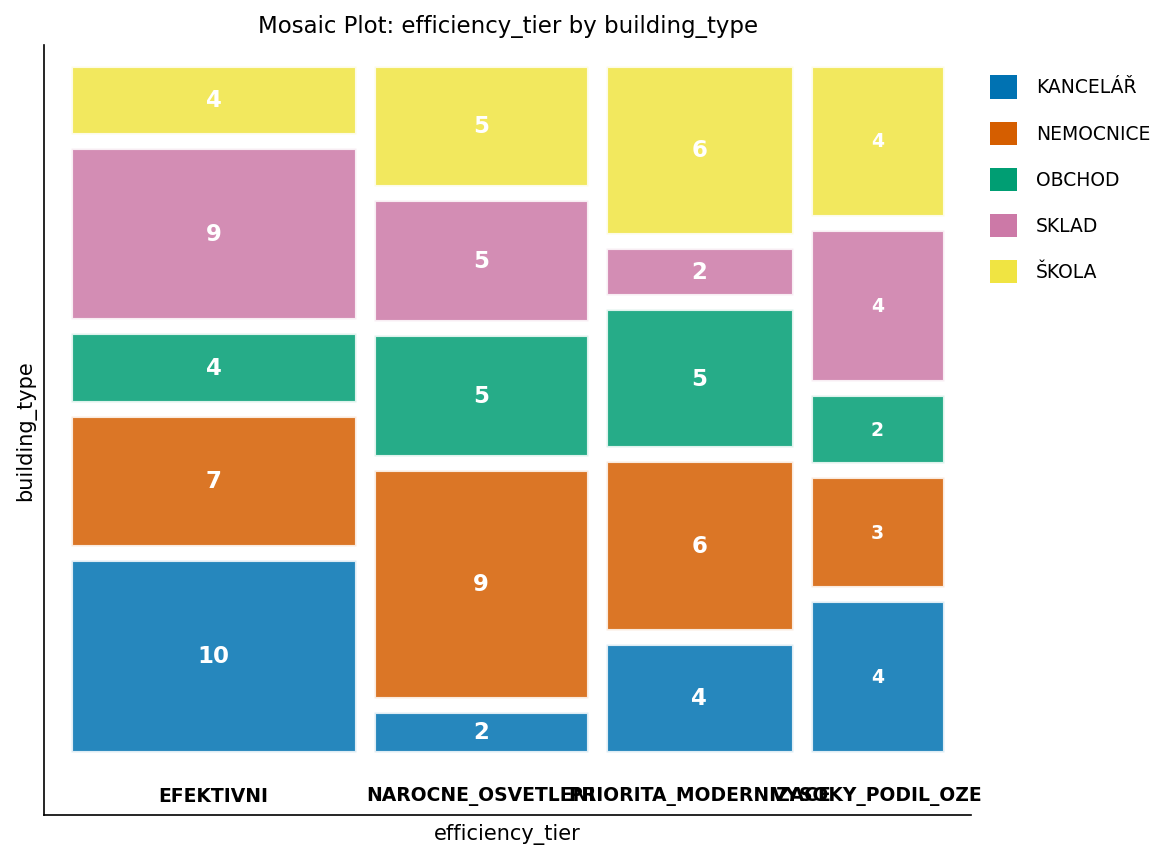

In [10]:
/* --------------------------------------------------------
   Profilování vybraného řešení k=4
   -------------------------------------------------------- */
data work.bldg_profiled;
    SLOUČIT work.building_metrics
          work.bldg_clust4 (PONECHAT=building_id CLUSTER distance);
    PODLE building_id;
SPUSTIT;

PROCEDURA PRŮMĚRY data=work.bldg_profiled mean std;
    TŘÍDA CLUSTER;
    PROMĚNNÁ eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct building_age;
    ŠTÍTEK eui='Energetická náročnost (EUI)'
          hvac_efficiency='Účinnost HVAC'
          envelope_r_value='Tepelný odpor obálky (R)'
          lighting_wpf='Hustota osvětlení (W/sqft)'
          renewable_pct='Podíl obnovitelných zdrojů (%)'
          building_age='Stáří budovy (roky)';
    NÁZEV 'Profily úrovní energetické účinnosti budov (k=4)';
SPUSTIT;

/* Označení úrovní účinnosti podle pozorovaných centroidů k=4:
   Shluk 4 = nejlepší HVAC (3,89) při nízkém EUI -> EFEKTIVNI
   Shluk 2 = nejvyšší podíl obnovitelných zdrojů (28 %), ale nejvyšší EUI -> VYSOKY_PODIL_OZE
   Shluk 3 = nejvyšší zátěž osvětlení, slabé HVAC, střední EUI -> NAROCNE_OSVETLENI
   Shluk 1 = nízké EUI, ale nejslabší HVAC + nejtenčí obálka -> PRIORITA_MODERNIZACE */
data work.bldg_tiered;
    NASTAVIT work.bldg_profiled;
    DÉLKA efficiency_tier $24;
    KDYŽ CLUSTER = 4 PAK efficiency_tier = 'EFEKTIVNI';
    JINAK KDYŽ CLUSTER = 2 PAK efficiency_tier = 'VYSOKY_PODIL_OZE';
    JINAK KDYŽ CLUSTER = 3 PAK efficiency_tier = 'NAROCNE_OSVETLENI';
    JINAK KDYŽ CLUSTER = 1 PAK efficiency_tier = 'PRIORITA_MODERNIZACE';
SPUSTIT;

PROCEDURA ČETNOSTI data=work.bldg_tiered;
    TABLES efficiency_tier * building_type / nocol norow;
    ŠTÍTEK efficiency_tier='Úroveň energetické účinnosti'
          building_type='Typ budovy';
    NÁZEV 'Úroveň energetické účinnosti podle typu budovy';
SPUSTIT;

---

### Interpretace

S volbou `REPLACE=FULL` konvergovala každá hodnota k čistě. Napříč čtyřmi řešeními rostl celkový R-kvadrát monotónně s k — 0,305 (k=3), 0,410 (k=4), 0,459 (k=5), 0,515 (k=6) — zatímco pseudo-F statistika vrcholila při **k=4 (22,23)** a poté klesala (20,13 při k=5, 19,93 při k=6). V kombinaci s minimální velikostí shluku 17 budov při k=4 (oproti 13 při k=5 a 10 při k=6) nabízí **řešení k=4** nejlepší rovnováhu mezi oddělením a stabilitou úrovní, a proto je dále profilováno níže.

Čtyři shluky řešení k=4 se mapují na jasně odlišné profily účinnosti (průměry z profilu PROC MEANS výše):

- **Efektivní (Shluk 4, n=34):** nejlépe vybavená skupina — nejvyšší účinnost HVAC (COP 3,89) při nízkém až středním EUI 72,4 kBtu/sqft/rok, s odpovídající obálkou (R 18,8) a mírným podílem obnovitelných zdrojů (11,0 %).
- **S vysokým podílem obnovitelných zdrojů (Shluk 2, n=17):** absolutně nejvyšší spotřebitelé (EUI 122,6), ale zdaleka i nejvyšší podíl obnovitelných zdrojů (28,2 %), se středním HVAC (COP 3,42). Vysoký výkon spárovaný s vlastní výrobou energie na místě.
- **S náročným osvětlením (Shluk 3, n=26):** střední EUI (94,0) tažené nejvyšší hustotou výkonu osvětlení (1,35 W/sqft) a druhým nejslabším HVAC (COP 2,42), navzdory nejsilnější obálce (R 19,6).
- **S prioritou modernizace (Shluk 1, n=23):** nízké EUI na papíře (63,8), ale nejslabší HVAC (COP 2,28) a nejtenčí obálka (R 12,5) — budovy, které jsou malé nebo málo využívané, přesto špatně vybavené, jasní kandidáti na modernizaci obálky a HVAC.

Křížová tabulace úrovně podle typu budovy ukazuje, že kanceláře (10) a sklady (9) dominují v efektivní úrovni, zatímco nemocnice se soustřeďují v úrovni s náročným osvětlením (9 z 26). Úroveň s prioritou modernizace je rozprostřená napříč typy, v čele s nemocnicemi a školami (po 6 z 23). Pro návrh programu jsou 23 budov s prioritou modernizace a 26 budov s náročným osvětlením přirozeným cílem pro pobídky na HVAC, respektive osvětlení, zatímco 17 budov s vysokým podílem obnovitelných zdrojů — které již vyrábějí energii na místě — je vhodnějších pro snížení poptávky než pro další rabaty na výrobu.

---

In [11]:
/* --------------------------------------------------------
   Export úrovní energetické účinnosti budov a profilů centroidů
   -------------------------------------------------------- */
PROCEDURA EXPORTOVAT data=work.bldg_tiered
    OUTFILE='building_efficiency_tiers.csv'
    DBMS=csv REPLACE;
SPUSTIT;

PROCEDURA EXPORTOVAT data=work.bldg_cent4
    OUTFILE='efficiency_tier_centroids.csv'
    DBMS=csv REPLACE;
SPUSTIT;


NOTE: PROC EXPORT data=work.bldg_tiered outfile=building_efficiency_tiers.csv

NOTE: Exported 100 rows to building_efficiency_tiers.csv.
NOTE: PROC EXPORT data=work.bldg_cent4 outfile=efficiency_tier_centroids.csv

NOTE: Exported 4 rows to efficiency_tier_centroids.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Důvěrné
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Poháněno platformou <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>